In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unittest
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_error
from datetime import datetime, timedelta

In [ ]:
class StockDataHandler:
    def __init__(self):
        self.raw_data = {}
        self.cleaned_data = {}
        self.tickers = [] # list to store tickers for the StockAnalysis class to use

    def dl_data(self, tickers, start=None, end=None, interval="1d"):
        self.tickers = tickers
        for t in tickers:
            df = yf.download(t, start=start, end=end, interval=interval, progress=False, auto_adjust=True)
            if df.empty:
                continue
            df.index = pd.to_datetime(df.index)
            df = df.sort_index()
            self.raw_data[t] = df
    def clean_data(self, fill_method="ffill"):
        for t, df in self.raw_data.items():
            d = df.copy()
            if isinstance(d.columns, pd.MultiIndex):
                d.columns = d.columns.droplevel(1)
            d.columns = d.columns.astype(str)
            if fill_method == "ffill":
                d = d.ffill().bfill()
            elif fill_method == "bfill":
                d = d.bfill().ffill()
            elif fill_method == "drop":
                d = d.dropna()
            for col in d.columns:
                d[col] = pd.to_numeric(d[col], errors="coerce")
            d = d.dropna()
            self.cleaned_data[t] = d

    def get_clean_data(self, ticker):
        if ticker not in self.cleaned_data:
            raise ValueError(f"Data for {ticker} not found. Run dl_data and clean_data first.")
        return self.cleaned_data[ticker].copy()

    def get_data(self, ticker):
        return self.get_clean_data(ticker)

    def check_data_quality(self):
        for ticker, df in self.cleaned_data.items():
            missing = df.isnull().sum().sum()
            print(f"Ticker: {ticker} | Missing Values: {missing} | Shape: {df.shape}")

class TestStockDataHandler(unittest.TestCase):

    def setUp(self):
        self.ticker = "AAPL" #change this to the stock ticker you want to test
        self.handler = StockDataHandler()

        end = datetime.today()
        start = end - timedelta(days=60)

        self.handler.dl_data(
            [self.ticker],
            start=start.strftime("%Y-%m-%d"),
            end=end.strftime("%Y-%m-%d"),
            interval="1d"
        )
        self.handler.clean_data()

    def test_raw_data_stored(self):
        self.assertIn(self.ticker, self.handler.raw_data)
        df_raw = self.handler.raw_data[self.ticker]
        self.assertGreater(len(df_raw), 0)

    def test_clean_data_stored(self):
        self.assertIn(self.ticker, self.handler.cleaned_data)
        df_clean = self.handler.cleaned_data[self.ticker]
        self.assertGreater(len(df_clean), 0)

    def test_get_clean_data_returns_copy(self):
        df_clean = self.handler.get_clean_data(self.ticker)
        self.assertGreater(len(df_clean), 0)

        old_shape = self.handler.cleaned_data[self.ticker].shape
        df_clean["DummyColumn"] = 1
        new_shape_internal = self.handler.cleaned_data[self.ticker].shape
        self.assertEqual(old_shape, new_shape_internal)

    def test_get_clean_data(self):
        df1 = self.handler.get_clean_data(self.ticker)
        df2 = self.handler.get_data(self.ticker)
        self.assertTrue(df1.equals(df2))

    def test_check_data_quality_runs(self):
        self.handler.check_data_quality()


if __name__ == "__main__":
       unittest.main(argv=['first-arg-is-ignored'], exit=False)

.

Ticker: AAPL | Missing Values: 0 | Shape: (39, 5)


....
----------------------------------------------------------------------
Ran 5 tests in 1.798s

OK


In [ ]:
##Defining a Stock Analysis Class

class Stock_Analysis():

   ##Creating the constructor function and initialize the attributes
    def __init__(self, ticker, start_date, end_date):
        self.ticker = str(ticker)
        self.start_date = start_date
        self.end_date = end_date

        self.data = None
        self.data_df_close = None
        self.lowest_prices = None
        self.return_value = None

    ##Defining a function to fetch basic statistics from Yahoo Finance
    def fetch_basic_statitiscs(self):
        ticker_stats = yf.Ticker(self.ticker)

        info = ticker_stats.info  # creating a dictionary to store the fundamentals

        stats = {
            "longName": info.get("longName"),
            "sector": info.get("sector"),
            "industry": info.get("industry"),
            "marketCap": info.get("marketCap"),
            "beta": info.get("beta"),
            "trailingPE": info.get("trailingPE"),
            "forwardPE": info.get("forwardPE"),
            "dividendYield": info.get("dividendYield"),
            "trailingEps": info.get("trailingEps"),
            "currentPrice": info.get("currentPrice"),
            "52WeekHigh": info.get("fiftyTwoWeekHigh"),
            "52WeekLow": info.get("fiftyTwoWeekLow")}

        self.basic_stats = stats
        return stats

    ##Defining a function so that the inputs are in the correct format as MM/DD/YYYY
    def parse_mmddyyyy(self, s: str) -> pd.Timestamp:
        # Interpreting '1/12/2024' as MM/DD/YYYY (Jan 12, 2024)
        return pd.to_datetime(s, format="%m/%d/%Y")

    ##Defining a function to download the data from yahoo finance in a dataframe for easy use and handle MultiIndex columns
    def simple_analysis(self):
        ticker = self.ticker
        start = self.parse_mmddyyyy(self.start_date)
        end   = self.parse_mmddyyyy(self.end_date)
        data = yf.download(ticker, start, end)

        # In case yfinance returned MultiIndex columns, select the ticker and flatten
        if isinstance(data.columns, pd.MultiIndex):
        # to take the subcolumns for this ticker, e.g. ('Close','AAPL') -> 'Close'
            data = data.xs(ticker, axis=1, level=1) ##creating a simple dataframe for the specific ticker
            data.columns = data.columns.astype(str)  # now: 'Open','High','Low','Close','Adj Close','Volume'

        ##Storing the data and making columns for analysis
        self.data = data
        self.data.index = pd.to_datetime(self.data.index)

        # these now work because 'Close' is a normal column
        self.data["closing"] = self.data["Close"]
        self.data["daily_change"] = self.data["closing"].diff()

        # Closing prices only with column name as ticker
        self.data_df_close = self.data[["Close"]].rename(columns={"Close": self.ticker})


    ##Defining an function to find the return between the two entered dates and ensuring the dates exist in the index
    def find_return(self, start_date, end_date):
        data = self.data_df_close

        start_date = self.parse_mmddyyyy(start_date)
        end_date = self.parse_mmddyyyy(end_date)
        ticker = self.ticker

        # Ensuring that the dates exist in index in case of weekends/holidays
        start_date = data.index[data.index.get_indexer([start_date], method="bfill")[0]]
        end_date   = data.index[data.index.get_indexer([end_date],   method="bfill")[0]]

        start_price = data.loc[start_date, ticker]
        end_price   = data.loc[end_date,   ticker]
        returns = ((end_price - start_price) / start_price) * 100
        returns = round(returns, 2)

        self.return_value = {
            "ticker": ticker,
            "start_date": start_date,
            "end_date": end_date,
            "return_pct": returns,
        }
        return returns

    ##Defining a function to create an interactive plot of the closing price of the chosen stock price
    def interactive_plot(self, title="Interactive prices"):
        df = self.data_df_close
        ##Checking with isinstance if the dataframe is multi index or series and converting it to a single column dataframe if it is so
        if isinstance(df, pd.DataFrame) and isinstance(df.columns, pd.MultiIndex):
            df = df["Close"].to_frame(name=self.ticker)
        elif isinstance(df, pd.Series):
            df = df.to_frame(name=self.ticker)

        print("-------Interactive Plot-------")
        print("Hover around the graph to see the closing prices for each date!!!")

        fig = px.line(df, x=df.index, y=df.columns[0], title=title)
        fig.show()

    def candlestick_plot(self):
        # working on a local copy of self.data
        data = self.data.copy()

        # Handle MultiIndex columns from yfinance
        if isinstance(data.columns, pd.MultiIndex):
            data = data.xs(self.ticker, axis=1, level=1)

        # Standardize column names and ensure datetime index
        data.columns = data.columns.str.strip().str.title()
        data.index = pd.to_datetime(data.index).tz_localize(None)

        # Now these columns exist
        data = data.dropna(subset=["Open", "High", "Low", "Close"])
        print("-------Candlestick Plot-------")
        print("Interactive candlestick chart for opening, high, low and closing price analysis")
        # Plotly candlestick
        fig = go.Figure(
            [
                go.Candlestick(
                    x=data.index,
                    open=data["Open"],
                    high=data["High"],
                    low=data["Low"],
                    close=data["Close"],
                )
            ]
        )
        fig.update_layout(
            template="plotly_white",
            xaxis_rangeslider_visible=False,
            title=f"{self.ticker} Candlestick Chart",
        )
        fig.show()
        print("-------Interactive Plot for Volume-------")
        print("Interactive plot for volume for",self.ticker)
        fig2 = make_subplots(specs=[[{"secondary_y": True}]])
        fig2.add_trace(
            go.Scatter(x=data.index, y=data["Close"], name="Price"),
            secondary_y=False,
        )
        fig2.add_trace(
            go.Bar(x=data.index, y=data["Volume"], name="Volume"),
            secondary_y=True,
        )
        fig2.update_layout(title=f"{self.ticker} Price and Volume")
        fig2.show()

    ##Defining a function for support and resistance trading strategy
    def trading_support_resistance(self, bin_width=20):
        # work on a copy of self.data for safety
        data = self.data.copy()
        n = len(data)
        ##Creating arrays to store the calculated values for the strategy
        support_tolerance   = np.full(n, np.nan)
        resistance_tolerance = np.full(n, np.nan)
        support_count   = np.zeros(n, dtype=int)
        resistance_count = np.zeros(n, dtype=int)
        support_arr     = np.full(n, np.nan)
        resistance_arr  = np.full(n, np.nan)
        signal          = np.zeros(n, dtype=int)

        in_support = 0
        in_resist  = 0

        price = data['closing'].to_numpy()

        ##Calculating support and resistance levels along with the trading signals
        for x in range((bin_width - 1) + bin_width, n):
            low = x - bin_width + 1
            high = x + 1
            window = price[low:high]
            sup = window.min()
            res = window.max()
            rng = res - sup

            support_arr[x] = sup
            resistance_arr[x] = res
            support_tolerance[x] = sup + 0.2 * rng
            resistance_tolerance[x] = res - 0.2 * rng

            if resistance_tolerance[x] <= price[x] <= resistance_arr[x]:
                in_resist += 1
                resistance_count[x] = in_resist
                in_support = 0
            elif support_tolerance[x] >= price[x] >= support_arr[x]:
                in_support += 1
                support_count[x] = in_support
                in_resist = 0
            else:
                in_support = 0
                in_resist = 0

            if in_resist >= 2:
                signal[x] = 1
            elif in_support >= 2:
                signal[x] = 0
            else:
                signal[x] = signal[x - 1]

        # assign back once, index-aligned
        data.loc[:, 'sup_tolerance'] = support_tolerance
        data.loc[:, 'res_tolerance'] = resistance_tolerance
        data.loc[:, 'sup_count']     = support_count
        data.loc[:, 'res_count']     = resistance_count
        data.loc[:, 'sup']           = support_arr
        data.loc[:, 'res']           = resistance_arr
        data.loc[:, 'signal']        = signal
        data.loc[:, 'positions']     = data['signal'].diff()

        print("-------Support and Resistance Trading Strategy Plot-------")
        print("Support and resistance strategy for", self.ticker)

        fig = plt.figure(figsize=(14, 6))
        ax1 = fig.add_subplot(111, ylabel='Price in $')
        ax1.set_title(f'{self.ticker} Support and Resistance Trading Strategy')
        data['sup'].plot(ax=ax1, color='green')
        data['res'].plot(ax=ax1, color='blue')
        data['closing'].plot(ax=ax1, color='red')
        ax1.plot(
            data.loc[data.positions == 1.0].index,
            data.closing[data.positions == 1.0],
            '^', markersize=7, color='green', label='buy'
        )
        ax1.plot(
            data.loc[data.positions == -1.0].index,
            data.closing[data.positions == -1.0],
            'v', markersize=7, color='red', label='sell'
        )
        plt.legend()
        plt.show()

        # store results for summary
        self.sr_last_signal = data['signal'].iloc[-1]
        self.sr_last_position = data['positions'].iloc[-1]
        return data

    ## simple moving average tradig strategy
    def SMA_indictor(self, window= 5, window_1= 20):
        ##making a copy of the data for safety
        df = self.data[['Close']].copy()
        df.rename(columns={'Close': 'Close'}, inplace=True)

        # defining fast and slow SMA
        df['SMA_fast'] = df['Close'].rolling(window=window, min_periods=1).mean()
        df['SMA_slow'] = df['Close'].rolling(window=window_1, min_periods=1).mean()

        # shift by 1 day to avoid look‑ahead
        df['SMA_fast_shift'] = df['SMA_fast'].shift(1)
        df['SMA_slow_shift'] = df['SMA_slow'].shift(1)

        # trading signal: long = 1, short = -1, 0 = flat
        df['signal_SMA'] = np.where(df['SMA_fast_shift'] > df['SMA_slow_shift'], 1, 0)
        df['signal_SMA'] = np.where(df['SMA_fast_shift'] < df['SMA_slow_shift'],
                                -1, df['signal_SMA'])

        # log returns and strategy returns
        df['log_return'] = np.log(df['Close']).diff()
        df['log_return_trend'] = df['signal_SMA'] * df['log_return']

        # entry / exit points
        df['action'] = df['signal_SMA'].diff()
        cum_factor = np.exp(df['log_return_trend'].sum())
        total_return = cum_factor - 1 # as decimal
        total_return_pct = round(total_return * 100, 2)

        print("-------Simple Moving Average Trading Strategy Plot-------")
        print("SMA strategy for", self.ticker)
        print("Total SMA strategy return for the entered dates (%):", total_return_pct)
        self.sma_total_return_pct = total_return_pct
        n_days = df['log_return_trend'].count()
        ann_factor = 252
        annual_return = (1 + total_return) ** (ann_factor / n_days) - 1 if n_days > 0 else np.nan
        self.sma_annual_return_pct = round(annual_return * 100, 2)
        print("Annual SMA strategy return for the entered dates (%):", self.sma_annual_return_pct)

        # plot
        plt.figure(figsize=(14, 6))
        plt.grid(True, alpha=0.3)
        plt.plot(df.index, df['Close'], label='Close')
        plt.plot(df.index, df['SMA_fast'], label=f'SMA-{window}')
        plt.plot(df.index, df['SMA_slow'], label=f'SMA-{window_1}')
        plt.plot(df.loc[df['action'] == 2].index,
            df['SMA_fast'][df['action'] == 2],
            '^', color='g', markersize=12, label='Buy')
        plt.plot(df.loc[df['action'] == -2].index,
            df['SMA_slow'][df['action'] == -2],
            'v', color='r', markersize=12, label='Sell')
        plt.legend(loc=1)
        plt.title(f'{self.ticker} SMA strategy')
        plt.show()

        # store last signal for summary
        self.sma_last_signal = int(df['signal_SMA'].iloc[-1])
        self.sma_total_return_pct = round(total_return * 100, 2)
        self.sma_annual_return_pct = round(annual_return * 100, 2)
        return df

    def macd_trading(self, fast_span=12, slow_span=26, sig_span=9):
       ##creating a copy of the data
        data_v1 = self.data[['closing']].copy()

        # defiing EMAs for trading strategy
        data_v1['EMA_fast'] = data_v1['closing'].ewm(span=fast_span, adjust=False).mean()
        data_v1['EMA_slow'] = data_v1['closing'].ewm(span=slow_span, adjust=False).mean()

        # getting a MACD line, Signal line
        data_v1['MACD'] = data_v1['EMA_fast'] - data_v1['EMA_slow']
        data_v1['MACD_signal'] = data_v1['MACD'].ewm(span=sig_span, adjust=False).mean()

        # trading rule: MACD crosses Signal by using yesterday's values to avoid look-ahead
        data_v1['MACD_shift'] = data_v1['MACD'].shift(1)
        data_v1['MACD_signal_shift'] = data_v1['MACD_signal'].shift(1)
        data_v1['signal'] = np.where(
        data_v1['MACD_shift'] > data_v1['MACD_signal_shift'], 1,
        np.where(data_v1['MACD_shift'] < data_v1['MACD_signal_shift'], -1, 0))
        data_v1['positions'] = data_v1['signal'].diff()  # +2 buy, -2 sell

        data_v1['log_return'] = np.log(data_v1['closing']).diff()
        data_v1['signal_shift'] = data_v1['signal'].shift(1).fillna(0)   # use yesterday's signal
        data_v1['macd_log_return_trend'] = data_v1['signal_shift'] * data_v1['log_return']

        print("-------MACD Trading Strategy Plot-------")
        print("MACD strategy for", self.ticker)
        # total return of MACD strategy
        macd_cum_factor = np.exp(data_v1['macd_log_return_trend'].sum())
        macd_total_return = macd_cum_factor - 1
        macd_total_return_pct = round(macd_total_return * 100, 2)
        n_days = data_v1['macd_log_return_trend'].count()
        ann_factor = 252
        macd_annual_return = ((1 + macd_total_return) ** (ann_factor / n_days) - 1 if n_days > 0 else np.nan)
        macd_annual_return_pct = round(macd_annual_return * 100, 2)


        print("Total MACD strategy return for the entered dates (%):", macd_total_return_pct)
        print("Annual MACD strategy return for the entered dates(%):", macd_annual_return_pct)

        self.macd_total_return_pct = macd_total_return_pct
        self.macd_annual_return_pct = macd_annual_return_pct

        # plot
        fig = plt.figure(figsize=(14, 6))
        ax1 = fig.add_subplot(211, ylabel='Price in $')
        ax1.set_title(f'{self.ticker} MACD Trading Strategy')
        data_v1['closing'].plot(ax=ax1, color='red', label='closing')
        data_v1['EMA_fast'].plot(ax=ax1, color='blue', label=f'EMA {fast_span}')
        data_v1['EMA_slow'].plot(ax=ax1, color='green', label=f'EMA {slow_span}')
        ax1.plot(data_v1.loc[data_v1.positions == 2].index,
        data_v1.closing[data_v1.positions == 2],
        '^', markersize=7, color='green', label='buy')
        ax1.plot(
        data_v1.loc[data_v1.positions == -2].index,
        data_v1.closing[data_v1.positions == -2],
        'v', markersize=7, color='red', label='sell')
        ax1.legend(loc='best')

        ax2 = fig.add_subplot(212, ylabel='MACD')
        data_v1['MACD'].plot(ax=ax2, color='black', label='MACD')
        data_v1['MACD_signal'].plot(ax=ax2, color='orange', label='Signal')
        ax2.axhline(0.0, color='gray', lw=1)
        ax2.legend(loc='best')
        plt.tight_layout()
        plt.show()

        self.macd_last_signal = int(data_v1['signal'].iloc[-1])
        return data_v1

    ##Defining a function for Bollinger Bands trading strategy
    def bbands_trading(self, window=20, k=2):
        # making a copy of the data
        data_v1 = self.data[['closing']].copy()

        # middle band (SMA), rolling std, upper/lower bands
        data_v1['BB_mid'] = data_v1['closing'].rolling(window, min_periods=window).mean()
        data_v1['BB_std'] = data_v1['closing'].rolling(window, min_periods=window).std()
        data_v1['BB_up']  = data_v1['BB_mid'] + k * data_v1['BB_std']
        data_v1['BB_dn']  = data_v1['BB_mid'] - k * data_v1['BB_std']

        close_shift = data_v1['closing'].shift(1)
        up_shift    = data_v1['BB_up'].shift(1)
        dn_shift    = data_v1['BB_dn'].shift(1)

        cross_up   = (close_shift <= up_shift) & (data_v1['closing'] > data_v1['BB_up'])
        cross_down = (close_shift >= dn_shift) & (data_v1['closing'] < data_v1['BB_dn'])
        ##Generating trading signals based on Bollinger Bands crossovers, long = 1, short = -1, flat = 0
        data_v1['signal'] = np.where(cross_up, 1, np.where(cross_down, -1, 0))
        data_v1['positions'] = data_v1['signal'].diff()  # +1 buy, -1 sell

        # ----- returns for BB strategy -----
        data_v1['log_return'] = np.log(data_v1['closing']).diff()
        data_v1['signal_shift'] = data_v1['signal'].shift(1).fillna(0)   # look-ahead avoidance
        data_v1['bb_log_return_trend'] = data_v1['signal_shift'] * data_v1['log_return']

        # total and annualized return
        bb_cum_factor = np.exp(data_v1['bb_log_return_trend'].sum())
        bb_total_return = bb_cum_factor - 1
        bb_total_return_pct = round(bb_total_return * 100, 2)

        n_days = data_v1['bb_log_return_trend'].count()
        ann_factor = 252
        bb_annual_return = ((1 + bb_total_return) ** (ann_factor / n_days) - 1) if n_days > 0 else np.nan
        bb_annual_return_pct = round(bb_annual_return * 100, 2)

        print("-------Bollinger Bands Trading Strategy Plot-------")
        print("Bollinger Bands strategy for", self.ticker)
        print("Total Bollinger Bands strategy return for entered dates (%):", bb_total_return_pct)
        print("Annual Bollinger Bands strategy return for entered dates(%):", bb_annual_return_pct)

        self.bb_total_return_pct = bb_total_return_pct
        self.bb_annual_return_pct = bb_annual_return_pct

        # ----- plot for Bollinger Band Strategy -----
        fig = plt.figure(figsize=(12, 7))
        ax1 = fig.add_subplot(211, ylabel='Price in $')
        ax1.set_title(f'{self.ticker} Bollinger Bands Trading Strategy')
        data_v1['closing'].plot(ax=ax1, color='red', label='closing')
        data_v1['BB_mid'].plot(ax=ax1, color='black', alpha=0.7, label=f'SMA {window}')
        data_v1['BB_up'].plot(ax=ax1, color='blue', alpha=0.8, label='BB upper')
        data_v1['BB_dn'].plot(ax=ax1, color='green', alpha=0.8, label='BB lower')

        ax1.fill_between(data_v1.index, data_v1['BB_dn'], data_v1['BB_up'],
                     color='steelblue', alpha=0.12, label='Band')

        ax1.plot(data_v1.loc[data_v1.positions == 1].index,
             data_v1.closing[data_v1.positions == 1], '^', markersize=7,
             color='green', label='buy')
        ax1.plot(data_v1.loc[data_v1.positions == -1].index,
             data_v1.closing[data_v1.positions == -1], 'v', markersize=7,
             color='red', label='sell')
        ax1.legend(loc='best')

        ax2 = fig.add_subplot(212, ylabel='BB metrics')
        data_v1['BB_pctB'] = (data_v1['closing'] - data_v1['BB_dn']) / (data_v1['BB_up'] - data_v1['BB_dn'])
        data_v1['BB_bw']   = (data_v1['BB_up'] - data_v1['BB_dn']) / data_v1['BB_mid']
        data_v1['BB_pctB'].plot(ax=ax2, color='purple', label='%B')
        data_v1['BB_bw'].plot(ax=ax2, color='orange', label='Bandwidth')
        ax2.axhline(0.0, color='gray', lw=1)
        ax2.axhline(1.0, color='gray', lw=1, ls='--')
        ax2.legend(loc='best')
        plt.tight_layout()
        plt.show()

        self.bb_df = data_v1
        return data_v1


    def run_all_simple_analysis(self):
        print("-----BASIC STOCK ANALYSIS-----")
        print("Running all analysis for", self.ticker)

        self.simple_analysis()
        self.find_return(self.start_date, self.end_date)
        self.interactive_plot('Interactive prices for')
        self.candlestick_plot()
        self.trading_support_resistance()
        self.SMA_indictor()
        self.macd_trading()
        self.bbands_trading()
        self.fetch_basic_statitiscs()
        self.summary()


    def summary(self):

        print("\n===== SUMMARY =====")
        if hasattr(self, "basic_stats"):
            s = self.basic_stats
            print("\nBasic statistics from Yahoo Finance:")
            if s.get("longName"):
                print("  Name:", s["longName"])
            if s.get("sector"):
                print("  Sector:", s["sector"])
            if s.get("industry"):
                print("  Industry:", s["industry"])
            if s.get("marketCap") is not None:
                print("  Market cap:", s["marketCap"])
            if s.get("trailingPE") is not None:
                print("  Trailing P/E:", s["trailingPE"])
            if s.get("beta") is not None:
                print("  Beta:", s["beta"])

        print("\n===== TRADING SUMMARY=====")

        print("Ticker:", self.ticker)
        print("Period:", self.start_date, "to", self.end_date)
        if self.return_value is not None:
            print("Buy and Hold return (%):", self.return_value["return_pct"])
        if hasattr(self, "sma_total_return_pct"):
            print("SMA strategy total return (%):", self.sma_total_return_pct)
        if hasattr(self, "sma_annual_return_pct"):
            print("SMA strategy annual return (%):", self.sma_annual_return_pct)
        if hasattr(self, "macd_total_return_pct"):
            print("MACD strategy total return (%):", self.macd_total_return_pct)
        if hasattr(self, "macd_annual_return_pct"):
            print("MACD strategy annual return (%):", self.macd_annual_return_pct)
        if hasattr(self, "bb_total_return_pct"):
            print("Bollinger Bands strategy total return (%):", self.bb_total_return_pct)
        if hasattr(self, "bb_annual_return_pct"):
            print("Bollinger Bands strategy annual return (%):", self.bb_annual_return_pct)

        print("===================\n")


In [ ]:
class FeatureEngine:
  def __init__(self, df, macro_data=None):
        self.df = df.copy()
        # macro_data in a dict: {'SPY': df, 'Oil': df, ...}
        self.macro_data = macro_data

  def add_technical_indicators(self):
        # Adds SMA, RSI, MACD, ROC
        # SMA (10 and 50)
        self.df['SMA_10'] = self.df['Close'].rolling(window=10).mean()
        self.df['SMA_50'] = self.df['Close'].rolling(window=50).mean()

        # RSI (14) - Relative Strength Index
        delta = self.df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        self.df['RSI'] = 100 - (100 / (1 + rs))

        # MACD - Moving Average Convergence Divergence
        ema12 = self.df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = self.df['Close'].ewm(span=26, adjust=False).mean()
        self.df['MACD'] = ema12 - ema26
        self.df['MACD_Signal'] = self.df['MACD'].ewm(span=9, adjust=False).mean()

        # ROC - Rate of Change over 10 days
        self.df['ROC'] = self.df['Close'].pct_change(periods=10) * 100

        return self

  def add_bollinger_bands(self, window=20, num_std=2):
        # Adds Bollinger Bands (Upper and Lower) to the dataframe
        rolling_mean = self.df['Close'].rolling(window=window).mean()
        rolling_std = self.df['Close'].rolling(window=window).std()

        self.df['BB_Upper'] = rolling_mean + (rolling_std * num_std)
        self.df['BB_Lower'] = rolling_mean - (rolling_std * num_std)
        return self

  def add_calendar_features(self):
        # Adds Monday/Friday flags and Month seasonality.
        # Is Monday
        self.df['Is_Monday'] = (self.df.index.dayofweek == 0).astype(int)

        # Is Friday
        self.df['Is_Friday'] = (self.df.index.dayofweek == 4).astype(int)

        # Month of Year
        self.df['Month'] = self.df.index.month

        # Start of Month - Days 1 to 5
        self.df['Is_Start_Month'] = (self.df.index.day <= 5).astype(int)

        # Middle of Month  - Days 14 to 16
        self.df['Is_Mid_Month'] = ((self.df.index.day >= 14) & (self.df.index.day <= 16)).astype(int)

  def add_macro_features(self):
        # Merges external macro factors like S&P500, VIX, Oil.
        if not self.macro_data:
            return self

        for name, macro_df in self.macro_data.items():

            macro_series = macro_df['Close'].rename(f'{name}_Close')

            self.df = self.df.merge(macro_series, left_index=True, right_index=True, how='left')

            if name in ['SP500', 'Oil', 'Treasury', 'VIX']:
                self.df[f'{name}_Return'] = self.df[f'{name}_Close'].pct_change()

        return self

  def prepare_target(self):
        # Creates Next Day's Close.
        self.df['Target'] = self.df['Close'].shift(-1)
        return self.df.dropna()

In [ ]:
class MLModel:
    def __init__(self, data, feature_cols, target_col='Target'):
        self.data = data
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.model = None
        self.scaler = StandardScaler()
        self.X_train, self.X_test, self.y_train, self.y_test = (None, None, None, None)

    def split_data(self, test_size=0.2, shuffle=False):
        X = self.data[self.feature_cols]
        y = self.data[self.target_col]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, shuffle=shuffle
        )
        print(f"Data Split: Train shape {self.X_train.shape}, Test shape {self.X_test.shape}")

    def train_model(self, model_type='LinearRegression'):
        if model_type == 'LinearRegression':
            self.model = LinearRegression()
        elif model_type == 'RandomForest':
            self.model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
        elif model_type == 'SVM':
            self.model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
        elif model_type == 'Ridge':
            self.model = Ridge(alpha=1.0)
        elif model_type == 'Lasso':
            self.model = Lasso(alpha=0.1)
        else:
            raise ValueError("Unknown model type")

        self.model.fit(self.X_train, self.y_train)
        print(f"Model {model_type} trained.")

    def evaluate(self):
        predictions = self.model.predict(self.X_test)
        mse = mean_squared_error(self.y_test, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(self.y_test, predictions)
        mae = mean_absolute_error(self.y_test, predictions)
        print(f"Evaluation Metrics ({self.model.__class__.__name__})")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R2 Score: {r2:.4f}")

        return predictions, self.y_test

/tmp/ipython-input-723/3919696027.py:49: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed

-----BASIC STOCK ANALYSIS-----
Running all analysis for AAPL
-------Interactive Plot-------
Hover around the graph to see the closing prices for each date!!!


-------Candlestick Plot-------
Interactive candlestick chart for opening, high, low and closing price analysis


-------Interactive Plot for Volume-------
Interactive plot for volume for AAPL


-------Support and Resistance Trading Strategy Plot-------
Support and resistance strategy for AAPL


/tmp/ipython-input-723/3919696027.py:228: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



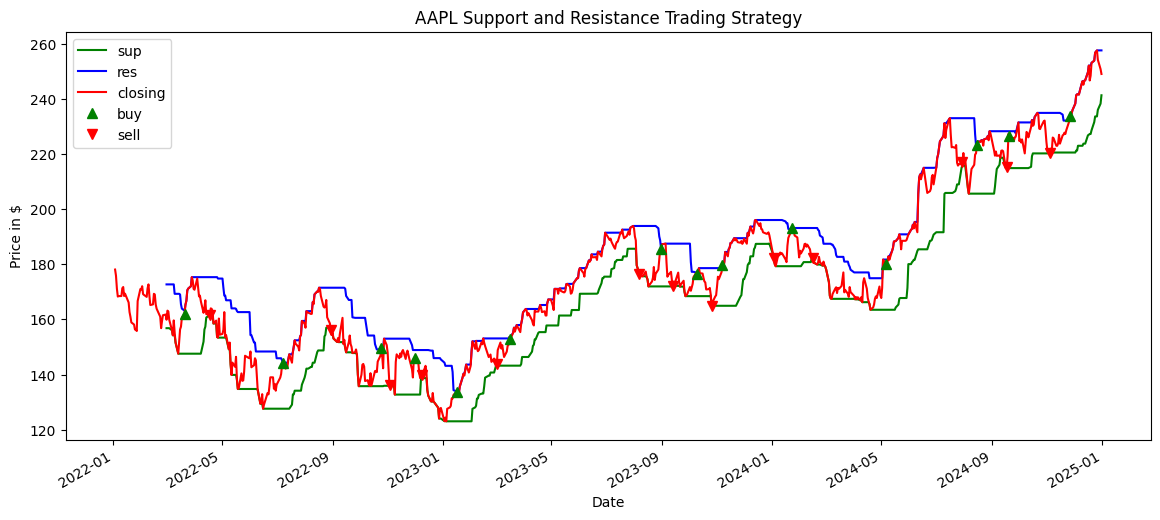

-------Simple Moving Average Trading Strategy Plot-------
SMA strategy for AAPL
Total SMA strategy return for the entered dates (%): 46.64
Annual SMA strategy return for the entered dates (%): 13.69


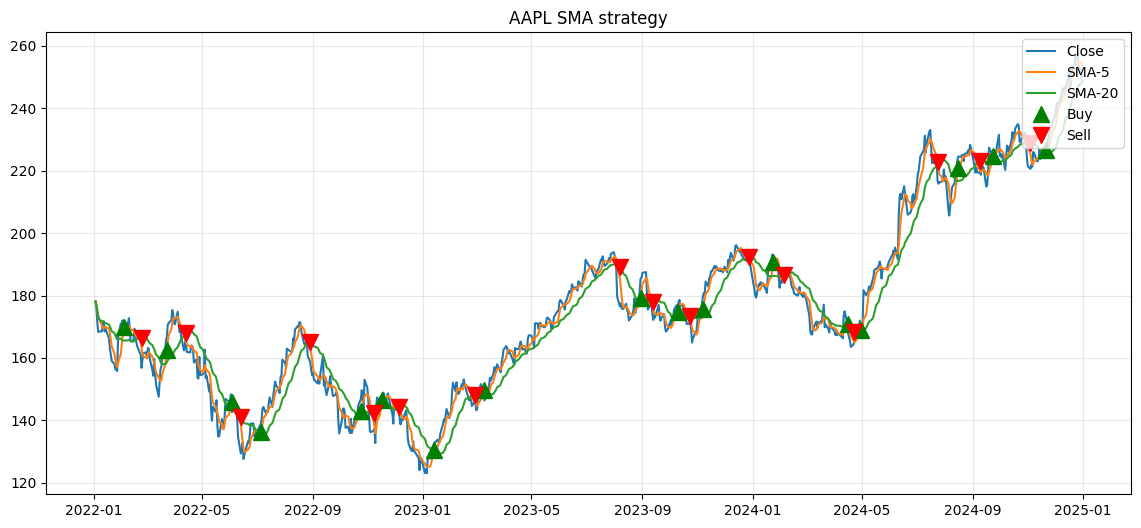

-------MACD Trading Strategy Plot-------
MACD strategy for AAPL
Total MACD strategy return for the entered dates (%): 48.43
Annual MACD strategy return for the entered dates(%): 14.15


/tmp/ipython-input-723/3919696027.py:356: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



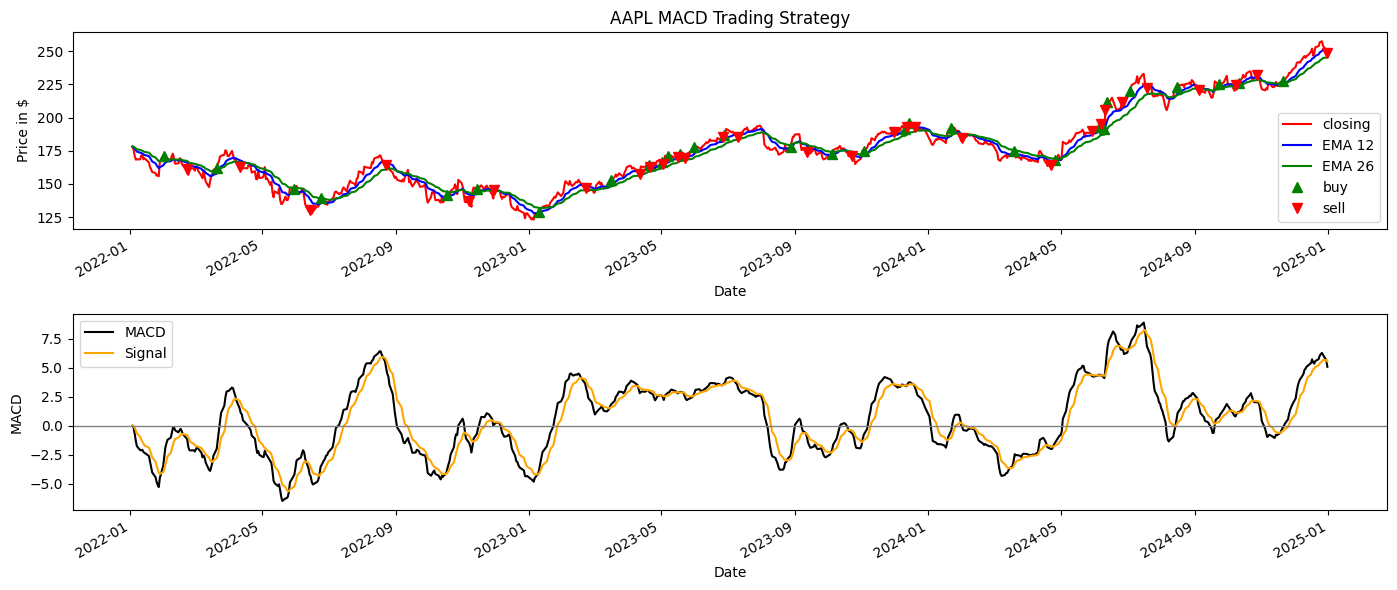

-------Bollinger Bands Trading Strategy Plot-------
Bollinger Bands strategy for AAPL
Total Bollinger Bands strategy return for entered dates (%): 4.42
Annual Bollinger Bands strategy return for entered dates(%): 1.46


/tmp/ipython-input-723/3919696027.py:432: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



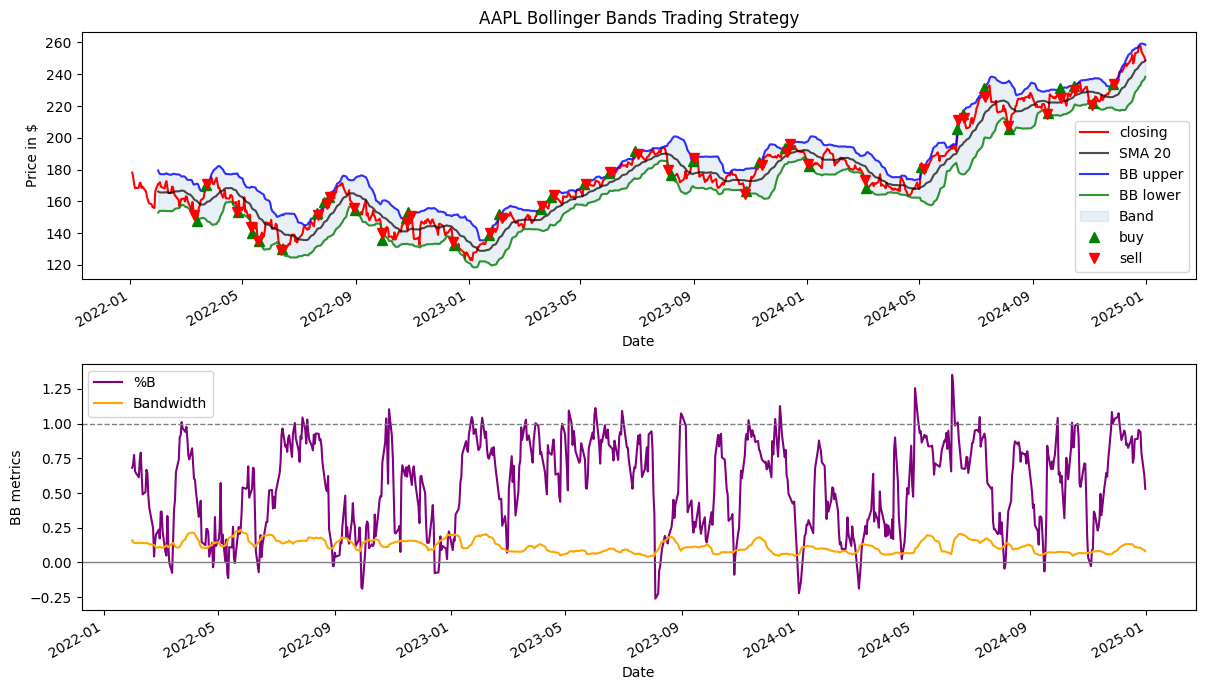


===== SUMMARY =====

Basic statistics from Yahoo Finance:
  Name: Apple Inc.
  Sector: Technology
  Industry: Consumer Electronics
  Market cap: 3882897899520
  Trailing P/E: 33.440506
  Beta: 1.107

===== TRADING SUMMARY=====
Ticker: AAPL
Period: 2022-01-01 00:00:00 to 2025-01-01 00:00:00
Buy and Hold return (%): 39.84
SMA strategy total return (%): 46.64
SMA strategy annual return (%): 13.69
MACD strategy total return (%): 48.43
MACD strategy annual return (%): 14.15
Bollinger Bands strategy total return (%): 4.42
Bollinger Bands strategy annual return (%): 1.46

Final Data Shape: (703, 27)


NameError: name 'StandardScaler' is not defined

In [ ]:
if __name__ == "__main__":

  # Define stock

  target_stock = "AAPL"
  start_date = pd.to_datetime("2022-01-01")
  end_date = pd.to_datetime("2025-01-01")

  macro_tickers = {
      'SP500': '^GSPC',
      'Treasury': '^TNX',
      'Oil': 'USO',
      'VIX': '^VIX'
      }

  all_tickers = [target_stock] + list(macro_tickers.values())

  # Fetch Data

  handler = StockDataHandler()
  handler.dl_data(all_tickers, start = start_date, end = end_date)
  handler.clean_data()

  stock_df = handler.get_data(target_stock)
  macro_data = {name : handler.get_data(ticker) for name, ticker in macro_tickers.items()}

  # Stock Analysis

  stock_analyzer = Stock_Analysis(target_stock, start_date, end_date)
  stock_analyzer.run_all_simple_analysis()

  # Feature Engineering

  engine = FeatureEngine(stock_df, macro_data = macro_data)
  engine.add_technical_indicators()
  engine.add_bollinger_bands()
  engine.add_calendar_features()
  engine.add_macro_features()

  ml_data = engine.prepare_target()

  print(f"Final Data Shape: {ml_data.shape}")

  # Machine Learning Implementation

  feature_cols = ['SMA_10', 'SMA_50','RSI', 'MACD', 'MACD_Signal', 'ROC', 'BB_Upper', 'BB_Lower', 'Is_Monday', 'Is_Friday', 'Month', 'SP500_Return', 'Treasury_Return', 'Oil_Return', 'VIX_Return']

  ml_model = MLModel(ml_data, feature_cols)
  ml_model.split_data()

  models = ['LinearRegression', 'RandomForest', 'SVM', 'Ridge', 'Lasso']

  best_rmse = float('inf')
  best_preds = None
  best_model_name = ""
  actuals = None

  for model_name in models:
      print(f"\n--- Testing {model_name} ---")
      ml_model.train_model(model_name)
      preds, y_test = ml_model.evaluate()
      current_rmse = np.sqrt(mean_squared_error(y_test, preds))
      if current_rmse < best_rmse:
          best_rmse = current_rmse
          best_preds = preds
          best_model_name = model_name
          actuals = y_test

  results_df = pd.DataFrame({
        'Date': actuals.index,
        'Actual': actuals.values,
        'Predicted': best_preds
    })

  fig = go.Figure()
  fig.add_trace(go.Scatter(x=results_df['Date'], y=results_df['Actual'], name='Actual Price', line=dict(color='blue')))
  fig.add_trace(go.Scatter(x=results_df['Date'], y=results_df['Predicted'], name='Predicted Price', line=dict(color='red', dash='dash')))
  fig.update_layout(title=f'ML Prediction vs Actual ({best_model_name})', xaxis_title='Date', yaxis_title='Price')
  fig.show()

  # Unit Testing

  suite = unittest.TestLoader().loadTestsFromTestCase(TestStockDataHandler)
  unittest.TextTestRunner(verbosity=2).run(suite)